In [107]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

In [108]:
from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass
import pandas as pd

@dataclass
class Grouped:
    name: str
    radius: float
    replicas_keys: list[str]

import pathlib
FIGDIR = pathlib.Path("figs_tesis")
FIGDIR.mkdir(exist_ok=True)

In [109]:
save_path = "/Users/niaggar/Results"

radius_values = [0.020, 0.035, 0.055, 0.075, 0.100, 0.175]
N_MEDIUM = 1.33
WAVELENGTH = 0.514 
k = 2 * np.pi * N_MEDIUM / WAVELENGTH
N_REPLICAS = 5

data_names = []
for rep in range(N_REPLICAS):
    for index, rad in enumerate(radius_values):
        name = f"radius_{rad:.3f}__rep{rep}"
        val = index * N_REPLICAS + rep
        full_name = f"{val:04d}_{name}"
        data_names.append((full_name, rf"R={rad*1000:.0f} $\mu$m"))

print(data_names)

[('0000_radius_0.020__rep0', 'R=20 $\\mu$m'), ('0005_radius_0.035__rep0', 'R=35 $\\mu$m'), ('0010_radius_0.055__rep0', 'R=55 $\\mu$m'), ('0015_radius_0.075__rep0', 'R=75 $\\mu$m'), ('0020_radius_0.100__rep0', 'R=100 $\\mu$m'), ('0025_radius_0.175__rep0', 'R=175 $\\mu$m'), ('0001_radius_0.020__rep1', 'R=20 $\\mu$m'), ('0006_radius_0.035__rep1', 'R=35 $\\mu$m'), ('0011_radius_0.055__rep1', 'R=55 $\\mu$m'), ('0016_radius_0.075__rep1', 'R=75 $\\mu$m'), ('0021_radius_0.100__rep1', 'R=100 $\\mu$m'), ('0026_radius_0.175__rep1', 'R=175 $\\mu$m'), ('0002_radius_0.020__rep2', 'R=20 $\\mu$m'), ('0007_radius_0.035__rep2', 'R=35 $\\mu$m'), ('0012_radius_0.055__rep2', 'R=55 $\\mu$m'), ('0017_radius_0.075__rep2', 'R=75 $\\mu$m'), ('0022_radius_0.100__rep2', 'R=100 $\\mu$m'), ('0027_radius_0.175__rep2', 'R=175 $\\mu$m'), ('0003_radius_0.020__rep3', 'R=20 $\\mu$m'), ('0008_radius_0.035__rep3', 'R=35 $\\mu$m'), ('0013_radius_0.055__rep3', 'R=55 $\\mu$m'), ('0018_radius_0.075__rep3', 'R=75 $\\mu$m'), ('0

# Linear Polarization study of RGD particles

In [110]:
folder_lineal = "study_homog_timeresolved__PLIN__beam2500"
sweep_data_lineal = load_sweep(folder_lineal, base_path=Path(save_path))

data_keys = list(sweep_data_lineal.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")


grouped_data = []
for rad in radius_values:
    replicas_keys = [key for key, _ in data_names if f"radius_{rad:.3f}" in key]
    grouped = Grouped(radius=rad, replicas_keys=replicas_keys, name=rf"R={rad*1000:.0f} $\mu$m")
    grouped_data.append(grouped)

print(grouped_data)

Loaded 30 datasets: ['0012_radius_0.055__rep2', '0021_radius_0.100__rep1', '0001_radius_0.020__rep1', '0016_radius_0.075__rep1', '0025_radius_0.175__rep0', '0007_radius_0.035__rep2', '0009_radius_0.035__rep4', '0015_radius_0.075__rep0', '0026_radius_0.175__rep1', '0023_radius_0.100__rep3', '0010_radius_0.055__rep0', '0005_radius_0.035__rep0', '0027_radius_0.175__rep2', '0019_radius_0.075__rep4', '0003_radius_0.020__rep3', '0014_radius_0.055__rep4', '0029_radius_0.175__rep4', '0017_radius_0.075__rep2', '0006_radius_0.035__rep1', '0028_radius_0.175__rep3', '0002_radius_0.020__rep2', '0011_radius_0.055__rep1', '0022_radius_0.100__rep2', '0018_radius_0.075__rep3', '0004_radius_0.020__rep4', '0024_radius_0.100__rep4', '0008_radius_0.035__rep3', '0000_radius_0.020__rep0', '0020_radius_0.100__rep0', '0013_radius_0.055__rep3']
[Grouped(name='R=20 $\\mu$m', radius=0.02, replicas_keys=['0000_radius_0.020__rep0', '0001_radius_0.020__rep1', '0002_radius_0.020__rep2', '0003_radius_0.020__rep3', '00

In [111]:
eps = 1e-30

def load_stitched(channel, k, lstar, th1, g1, th2, g2, key):
    theta_1 = th1[-1]                       # fin de la ventana fina
    lo = 0.9 * theta_1                       # inicio real de det_2 (solape)

    # --- chequeo de stitching: interpola det_1 sobre los bins de solape de det_2
    ov = (th2 >= lo) & (th2 <= theta_1)
    if ov.any():
        g1_on2 = np.interp(th2[ov], th1, g1)
        resid = np.abs(g2[ov] - g1_on2)
        if np.max(resid) > 0.05:            # umbral: 5% del enhancement
            print(f"[stitch WARN] {key} ch={channel}: max solape "
                  f"{np.max(resid):.3f} -- revisar normalizacion angulo solido")

    # une: det_1 completo + det_2 estrictamente por encima de theta_1
    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])
    q = k * lstar * theta
    return theta, q, g

def tail_baseline(q, y, q_min=25.0, n_min=5, frac=0.85):
    """Fondo en la cola, inmune a ventanas vacías.
    Usa q>q_min si hay puntos suficientes; si no, cae al tramo alto
    del q realmente disponible para ese radio."""
    q = np.asarray(q); y = np.asarray(y)
    m = q > q_min
    if np.count_nonzero(m) >= n_min:
        return np.median(y[m])
    q_cut = frac * np.nanmax(q)          # último ~15 % del q disponible
    m = q >= q_cut
    if np.count_nonzero(m) < n_min:
        idx = np.argsort(q)[-n_min:]     # los n_min puntos de mayor q
        return np.median(y[idx])
    return np.median(y[m])

def load_mean_enhancement(grouped_rad, basis, reduce, time_index, chanel, k):
    I_incoherent_total_1 = None
    I_incoherent_total_2 = None
    I_coherent_total_1 = None
    I_coherent_total_2 = None
    for key in grouped_rad.replicas_keys:
        sweep = sweep_data_lineal[key]

        p1 = cbs_profiles(sweep.processed_cbs("farfield_cbs_1"), basis=basis, time_index=time_index, reduce=reduce)
        p2 = cbs_profiles(sweep.processed_cbs("farfield_cbs_2"), basis=basis, time_index=time_index, reduce=reduce)

        if I_incoherent_total_1 is None:
            I_incoherent_total_1 = np.zeros_like(p1.incoherent[chanel])
            I_incoherent_total_2 = np.zeros_like(p2.incoherent[chanel])
            I_coherent_total_1 = np.zeros_like(p1.coherent[chanel])
            I_coherent_total_2 = np.zeros_like(p2.coherent[chanel])

        I_incoherent_total_1 = I_incoherent_total_1 + p1.incoherent[chanel]
        I_incoherent_total_2 = I_incoherent_total_2 + p2.incoherent[chanel]
        I_coherent_total_1 = I_coherent_total_1 + p1.coherent[chanel]
        I_coherent_total_2 = I_coherent_total_2 + p2.coherent[chanel]

    enhancement_1 = (I_coherent_total_1 + eps) / (I_incoherent_total_1 + eps)
    enhancement_2 = (I_coherent_total_2 + eps) / (I_incoherent_total_2 + eps)
    sweep0 = sweep_data_lineal[grouped_rad.replicas_keys[0]]
    p0_1 = cbs_profiles(sweep0.processed_cbs("farfield_cbs_1"), basis=basis, time_index=time_index, reduce=reduce)
    p0_2 = cbs_profiles(sweep0.processed_cbs("farfield_cbs_2"), basis=basis, time_index=time_index, reduce=reduce)
    theta_1 = p0_1.theta
    theta_2 = p0_2.theta

    lstar0 = sweep_data_lineal[grouped_rad.replicas_keys[0]].params_flat["transport_mean_free_path"]
    theta, q, enhancement = load_stitched(chanel, k, lstar0, theta_1, enhancement_1, theta_2, enhancement_2, grouped_rad.replicas_keys[0])

    return theta, q, enhancement

In [112]:
PHI_DEG = {0: 0, 1: 45, 2: 90}   # indices de set_phi_slices([0, pi/4, pi/2])

def get_profile(grouped_rad, phi_index, channel, time_index=0):
    """Perfil E(q) promediado sobre replicas, con baseline llevada a 1."""
    _, q, E = load_mean_enhancement(grouped_rad, linear, phi_cut(phi_index),
                                    time_index, channel, k)
    base = tail_baseline(q, E, q_min=25.0)
    return q, E - base + 1.0

def peak_height(theta, q, E, n=3):
    """E(0) estimado como mediana de los primeros n bins (robusto al ruido del apice)."""
    return np.median(E[:n])

def fwhm_q(theta, q, E, n=3):
    """Ancho total a mitad de altura en unidades de q, por interpolacion lineal."""
    E0 = peak_height(theta, q, E, n)
    half = 1.0 + 0.5 * (E0 - 1.0)
    below = np.where(E < half)[0]
    if len(below) == 0:
        return np.nan
    i = below[0]                                  # primer bin bajo el semi-maximo
    # interpolacion entre (i-1, i):
    q_half = q[i-1] + (half - E[i-1]) * (q[i] - q[i-1]) / (E[i] - E[i-1])
    return 2.0 * q_half                            # cono simetrico en theta

In [113]:
for g_ in grouped_data:
    g_.name = rf"${g_.radius*1000:.0f}$ nm"

import pathlib
FIGDIR = pathlib.Path("figs_tesis"); FIGDIR.mkdir(exist_ok=True)

In [114]:
def profile_one(sweep, key, phi_index, channel, time_index=0, basis=linear):
    """Perfil E(q) de UNA replica, baseline llevada a 1."""
    reducer = phi_cut(phi_index) if basis == linear else azimuthal_average
    sw = sweep[key]
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=basis,
                      time_index=time_index, reduce=reducer)
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=basis,
                      time_index=time_index, reduce=reducer)
    E1 = (p1.coherent[channel] + eps) / (p1.incoherent[channel] + eps)
    E2 = (p2.coherent[channel] + eps) / (p2.incoherent[channel] + eps)
    lst = 0
    if "transport_mean_free_path" in sw.params_flat:
        lst = sw.params_flat["transport_mean_free_path"]
    else:
        lst = sw.params_flat.get("lstar_sim", 0.0)
    theta, q, E = load_stitched(channel, k, lst, p1.theta, E1, p2.theta, E2, key)
    return theta, q, E - tail_baseline(q, E) + 1.0

def profile_stats(sweep, grouped_rad, phi_index, channel, time_index=0, basis=linear):
    """Media y desviacion estandar (ddof=1) sobre las replicas."""
    curves = []
    for key in grouped_rad.replicas_keys:
        theta, q, E = profile_one(sweep, key, phi_index, channel, time_index=time_index, basis=basis)
        curves.append(E)
    C = np.vstack(curves)
    return theta, q, C.mean(axis=0), C.std(axis=0, ddof=1)

def mirror(q, *ys):
    """Espejo -q..+q para presentacion estilo Iwai (valido: I(th,phi)=I(th,phi+pi))."""
    return (np.r_[-q[::-1], q],) + tuple(np.r_[y[::-1], y] for y in ys)

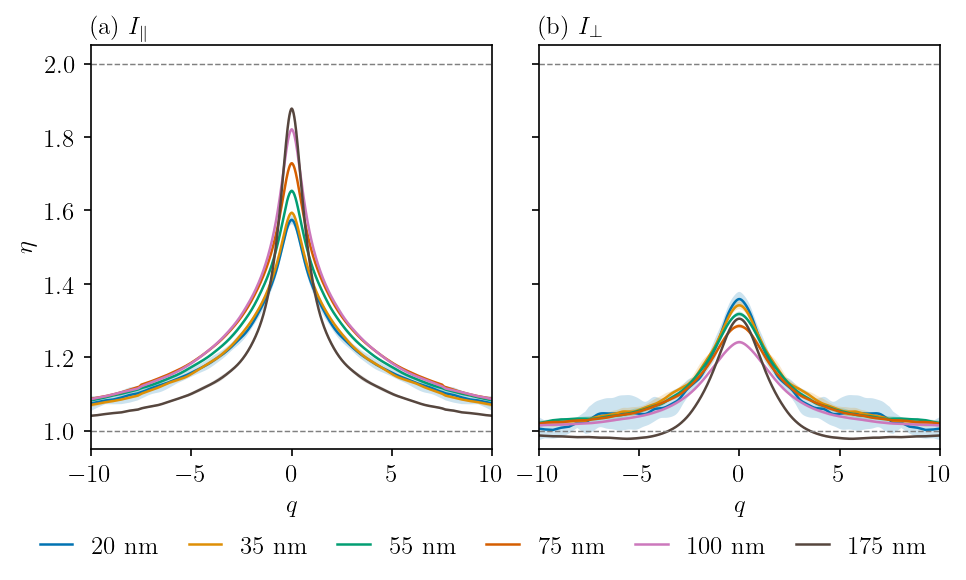

In [115]:
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.6*TEXTWIDTH_IN), sharey=True)

for c, g_ in zip(COL, grouped_data):
    for ax, ch in ((ax1, "co"), (ax2, "cross")):
        theta, q, m, s = profile_stats(sweep_data_lineal, g_, 0, ch)          # phi = 0 (X-scan)
        qs, ms, ss = mirror(q, m, s)
        ax.plot(qs, ms, color=c, label=g_.name)
        ax.fill_between(qs, ms - ss, ms + ss, color=c, alpha=0.20, lw=0)

for ax, t in ((ax1, r"(a) $I_\parallel$"), (ax2, r"(b) $I_\perp$")):
    ax.set_xlim(-10, 10);
    ax.set_ylim(0.95, 2.05)
    ax.set_xlabel(r"$q$")
    ax.set_title(t, loc="left")
    ax.axhline(2.0, ls="--", c="gray", lw=0.7)
    ax.axhline(1.0, ls="--", c="gray", lw=0.7)

ax1.set_ylabel(r"$\eta$")
fig.legend(*ax1.get_legend_handles_labels(),
           ncol=6, loc="outside lower center",
           frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "cbs_perfiles_co_cross_q_phi00.pdf")

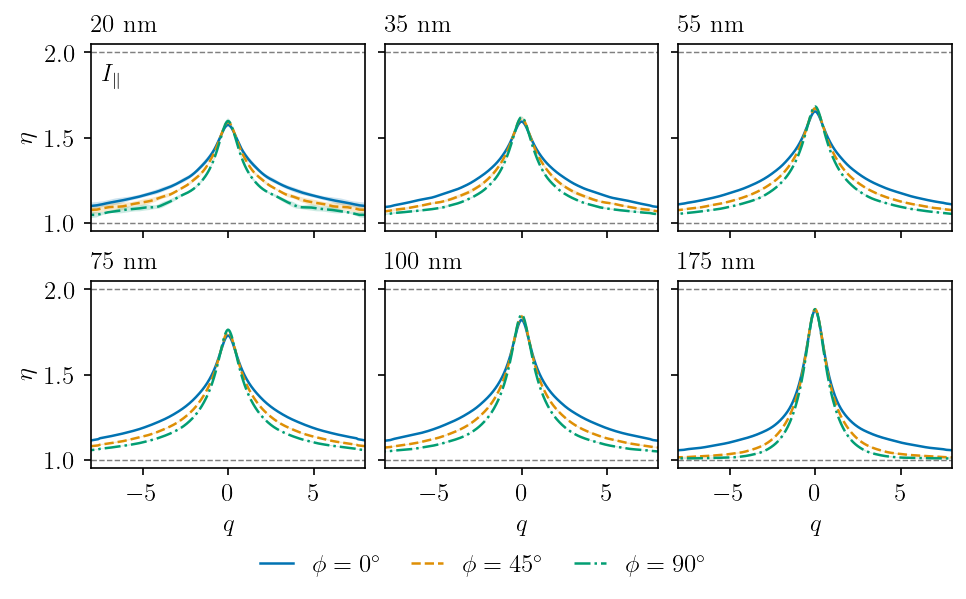

In [116]:
apply(width_frac=1.0)
fig, axes = plt.subplots(2, 3, figsize=(TEXTWIDTH_IN, 0.62*TEXTWIDTH_IN),
                         sharex=True, sharey=True)

for ax, g_ in zip(axes.flat, grouped_data):
    _, q, m00, s00 = profile_stats(sweep_data_lineal, g_, 0, "co", basis=linear)     # X-scan: phi=0
    _, _, m45, s45 = profile_stats(sweep_data_lineal, g_, 1, "co", basis=linear)     # Y-scan: phi=45
    _, _, m90, s90 = profile_stats(sweep_data_lineal, g_, 2, "co", basis=linear)     # Y-scan: phi=90
    
    qs, m00s, s00s, m45s, s45s, m90s, s90s = mirror(q, m00, s00, m45, s45, m90, s90)
    
    ax.plot(qs, m00s, color=COL[0], label=r"$\phi=0^\circ$")
    ax.fill_between(qs, m00s - s00s, m00s + s00s, color=COL[0], alpha=0.2, lw=0)

    ax.plot(qs, m45s, color=COL[1], ls="--", label=r"$\phi=45^\circ$")
    ax.fill_between(qs, m45s - s45s, m45s + s45s, color=COL[1], alpha=0.2, lw=0)

    ax.plot(qs, m90s, color=COL[2], ls="-.", label=r"$\phi=90^\circ$")
    ax.fill_between(qs, m90s - s90s, m90s + s90s, color=COL[2], alpha=0.2, lw=0)

    ax.set_title(g_.name, loc="left")
    ax.set_xlim(-8, 8); ax.set_ylim(0.95, 2.05); ax.grid(alpha=0.15)

    ax.axhline(2.0, ls="--", c="gray", lw=0.7)
    ax.axhline(1.0, ls="--",  c="gray", lw=0.7)
    ax.grid(False)
    

for ax in axes[1]:  ax.set_xlabel(r"$q$")
for ax in axes[:, 0]: ax.set_ylabel(r"$\eta$")

axes[0, 0].text(0.04, 0.90, r"$I_\parallel$", transform=axes[0, 0].transAxes,
                ha="left", va="top")

fig.legend(*axes[0, 0].get_legend_handles_labels(),
           ncol=6, loc="outside lower center",
           frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "cbs_anisotropia_xy_LIN.pdf")
plt.show()

In [117]:
def metric_stats(sweep, grouped_rad, phi_index, channel, fn, basis=linear):
    vals = [fn(*profile_one(sweep, key, phi_index, channel, basis=basis))
            for key in grouped_rad.replicas_keys]
    return np.mean(vals), np.std(vals, ddof=1)

R = np.array([g_.radius * 1000 for g_ in grouped_data])   # nm

res = {}
for pi in (0, 2):
    res[f"E0_{pi}"] = np.array([metric_stats(sweep_data_lineal, g_, pi, "co", peak_height)
                                for g_ in grouped_data])
    res[f"dq_{pi}"] = np.array([metric_stats(sweep_data_lineal, g_, pi, "co", fwhm_q)
                                for g_ in grouped_data])

# A_w por réplica (mismo par de perfiles por réplica -> correlación correcta)
Aw = []
for g_ in grouped_data:
    v = []
    for key in g_.replicas_keys:
        w0  = fwhm_q(*profile_one(sweep_data_lineal, key, 0, "co"))
        w90 = fwhm_q(*profile_one(sweep_data_lineal, key, 2, "co"))
        v.append((w0 - w90) / (w0 + w90))
    Aw.append((np.mean(v), np.std(v, ddof=1)))
Aw = np.array(Aw)

print(Aw)

[[0.26682282 0.03624697]
 [0.25561072 0.01294772]
 [0.24527684 0.00696026]
 [0.23078076 0.00507431]
 [0.19451545 0.00845084]
 [0.06869585 0.00426991]]


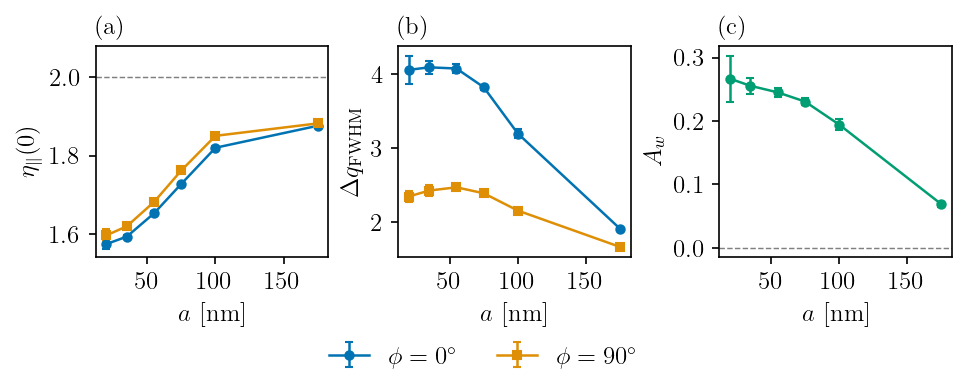

In [118]:
apply(width_frac=1.0)
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(TEXTWIDTH_IN, 0.4*TEXTWIDTH_IN))

CUT_STYLE = ((0, "o", COL[0], r"$\phi = 0^\circ$"),
             (2, "s", COL[1], r"$\phi = 90^\circ$"))

for pi, mk, c, lb in CUT_STYLE:
    a1.errorbar(R, res[f"E0_{pi}"][:, 0], res[f"E0_{pi}"][:, 1],
                marker=mk, ms=4, capsize=2, color=c, label=lb)
    a2.errorbar(R, res[f"dq_{pi}"][:, 0], res[f"dq_{pi}"][:, 1],
                marker=mk, ms=4, capsize=2, color=c, label=lb)

a3.errorbar(R, Aw[:, 0], Aw[:, 1], marker="o", ms=4, capsize=2, color=COL[2])

# (a) altura del pico
a1.set_title("(a)", loc="left")
a1.set_ylabel(r"$\eta_\parallel(0)$")
a1.axhline(2.0, ls="--", c="gray", lw=0.7)
a1.set_ylim(top=2.08)

# (b) ancho del cono
a2.set_title("(b)", loc="left")
a2.set_ylabel(r"$\Delta q_{\mathrm{FWHM}}$")
# a2.axhline(0.73, ls="--", c="gray", lw=0.7)
# a2.text(R.min(), 0.80, "difusivo", fontsize=8, color="gray", va="bottom")

# (c) asimetría azimutal del ancho
a3.set_title("(c)", loc="left")
a3.set_ylabel(r"$A_w$")
a3.axhline(0.0, ls="--", c="gray", lw=0.7)

for ax in (a1, a2, a3):
    ax.set_xlabel(r"$a$ [nm]")
    ax.grid(False)

fig.legend(*a1.get_legend_handles_labels(),
           ncol=2, loc="outside lower center",
           frameon=False, columnspacing=1.6, handlelength=1.6)

fig.savefig(FIGDIR / "cbs_anisotropia_vs_R.pdf")
plt.show()

# Circular Polarization study of RGD particles

In [119]:
folder_circular = "study_homog_timeresolved__PCIR__beam2500"
sweep_data_circular = load_sweep(folder_circular, base_path=Path(save_path))

data_keys = list(sweep_data_circular.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")


grouped_data_circular = []
for rad in radius_values:
    replicas_keys = [key for key, _ in data_names if f"radius_{rad:.3f}" in key]
    grouped = Grouped(radius=rad, replicas_keys=replicas_keys, name=rf"{rad*1000:.0f} nm")
    grouped_data_circular.append(grouped)

print(grouped_data_circular)

Loaded 30 datasets: ['0012_radius_0.055__rep2', '0021_radius_0.100__rep1', '0001_radius_0.020__rep1', '0016_radius_0.075__rep1', '0025_radius_0.175__rep0', '0007_radius_0.035__rep2', '0009_radius_0.035__rep4', '0015_radius_0.075__rep0', '0026_radius_0.175__rep1', '0023_radius_0.100__rep3', '0010_radius_0.055__rep0', '0005_radius_0.035__rep0', '0027_radius_0.175__rep2', '0019_radius_0.075__rep4', '0003_radius_0.020__rep3', '0014_radius_0.055__rep4', '0029_radius_0.175__rep4', '0017_radius_0.075__rep2', '0006_radius_0.035__rep1', '0028_radius_0.175__rep3', '0002_radius_0.020__rep2', '0011_radius_0.055__rep1', '0022_radius_0.100__rep2', '0018_radius_0.075__rep3', '0004_radius_0.020__rep4', '0024_radius_0.100__rep4', '0008_radius_0.035__rep3', '0000_radius_0.020__rep0', '0020_radius_0.100__rep0', '0013_radius_0.055__rep3']
[Grouped(name='20 nm', radius=0.02, replicas_keys=['0000_radius_0.020__rep0', '0001_radius_0.020__rep1', '0002_radius_0.020__rep2', '0003_radius_0.020__rep3', '0004_radi

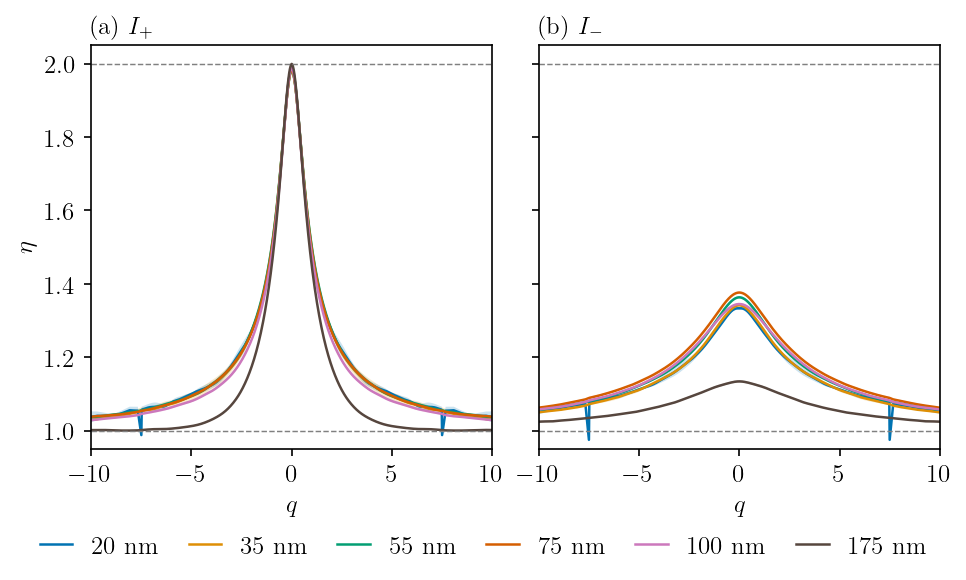

In [120]:
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.6*TEXTWIDTH_IN), sharey=True)

for c, g_ in zip(COL, grouped_data_circular):
    for ax, ch in ((ax1, "cross"), (ax2, "co")):
        theta, q, m, s = profile_stats(sweep_data_circular, g_, 0, ch, basis=circular)          # phi = 0 (X-scan)
        qs, ms, ss = mirror(q, m, s)
        ax.plot(qs, ms, color=c, label=g_.name)
        ax.fill_between(qs, ms - ss, ms + ss, color=c, alpha=0.20, lw=0)

for ax, t in ((ax1, "(a) $I_+$"), (ax2, "(b) $I_-$")):
    ax.set_xlim(-10, 10); ax.set_ylim(0.95, 2.05)
    ax.set_xlabel(r"$q$")
    ax.set_title(t, loc="left")
    ax.grid(False)
    ax.axhline(1.0, ls="--", c="gray", lw=0.7)
    ax.axhline(2.0, ls="--", c="gray", lw=0.7)

ax1.set_ylabel(r"$\eta$")
fig.legend(*ax1.get_legend_handles_labels(),
           ncol=6, loc="outside lower center",
           frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "cbs_perfiles_co_cross_circular.pdf")
plt.show()

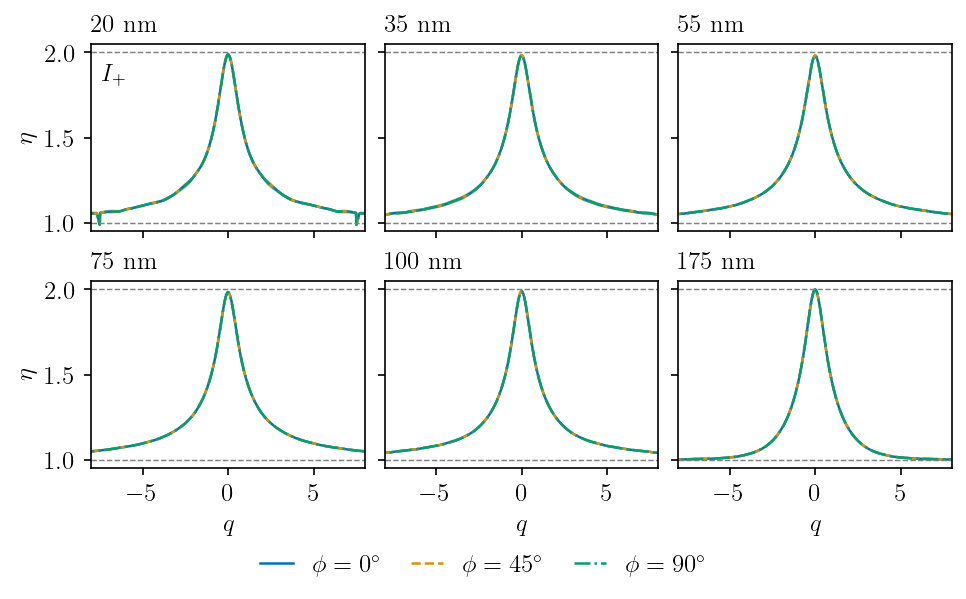

In [121]:
apply(width_frac=1.0)
fig, axes = plt.subplots(2, 3, figsize=(TEXTWIDTH_IN, 0.62*TEXTWIDTH_IN),
                         sharex=True, sharey=True)

for ax, g_ in zip(axes.flat, grouped_data_circular):
    _, q, m00, s00 = profile_stats(sweep_data_circular, g_, 0, "cross", basis=circular)     # X-scan: phi=0
    _, _, m45, s45 = profile_stats(sweep_data_circular, g_, 1, "cross", basis=circular)     # Y-scan: phi=45
    _, _, m90, s90 = profile_stats(sweep_data_circular, g_, 2, "cross", basis=circular)     # Y-scan: phi=90
    
    qs, m00s, s00s, m45s, s45s, m90s, s90s = mirror(q, m00, s00, m45, s45, m90, s90)
    
    ax.plot(qs, m00s, color=COL[0], label=r"$\phi=0^\circ$")
    ax.fill_between(qs, m00s - s00s, m00s + s00s, color=COL[0], alpha=0.2, lw=0)

    ax.plot(qs, m45s, color=COL[1], ls="--", label=r"$\phi=45^\circ$")
    ax.fill_between(qs, m45s - s45s, m45s + s45s, color=COL[1], alpha=0.2, lw=0)

    ax.plot(qs, m90s, color=COL[2], ls="-.", label=r"$\phi=90^\circ$")
    ax.fill_between(qs, m90s - s90s, m90s + s90s, color=COL[2], alpha=0.2, lw=0)

    ax.set_title(g_.name, loc="left")
    ax.set_xlim(-8, 8); ax.set_ylim(0.95, 2.05); ax.grid(alpha=0.15)

    ax.axhline(2.0, ls="--", c="gray", lw=0.7)
    ax.axhline(1.0, ls="--",  c="gray", lw=0.7)
    ax.grid(False)
    

for ax in axes[1]:  ax.set_xlabel(r"$q$")
for ax in axes[:, 0]: ax.set_ylabel(r"$\eta$")

axes[0, 0].text(0.04, 0.90, r"$I_+$", transform=axes[0, 0].transAxes,
                ha="left", va="top")

fig.legend(*axes[0, 0].get_legend_handles_labels(),
           ncol=6, loc="outside lower center",
           frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "cbs_anisotropia_xy.pdf")
plt.show()

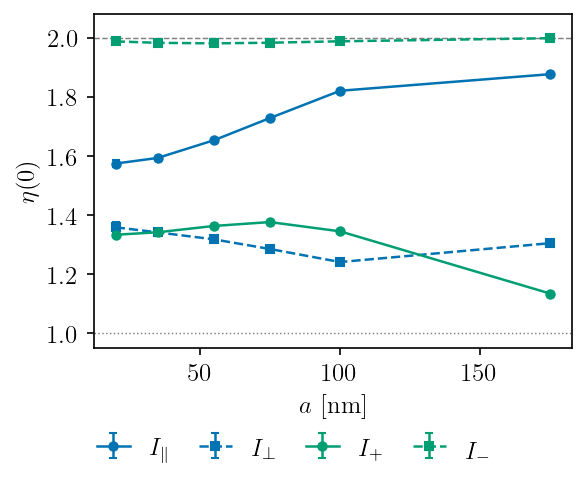

In [122]:
apply(width_frac=0.6)
fig, ax = plt.subplots(figsize=(0.6*TEXTWIDTH_IN, 0.5*TEXTWIDTH_IN))

# tras el fix de circular(): "co" = h||h, "cross" = h⊥h  (natural otra vez)
casos = [
    (sweep_data_lineal,   grouped_data,          linear,   "co",    r"$I_\parallel$", COL[0], "o", "-"),
    (sweep_data_lineal,   grouped_data,          linear,   "cross", r"$I_\perp$",     COL[0], "s", "--"),
    (sweep_data_circular, grouped_data_circular, circular, "co", r"$I_+$",         COL[2], "o", "-"),
    (sweep_data_circular, grouped_data_circular, circular, "cross",    r"$I_-$",         COL[2], "s", "--"),
]

for sweep, gd, bs, ch, lb, c, mk, ls in casos:
    Rc = np.array([g_.radius * 1000 for g_ in gd])
    E  = np.array([metric_stats(sweep, g_, 0, ch, peak_height, basis=bs) for g_ in gd])
    ax.errorbar(Rc, E[:, 0], E[:, 1], marker=mk, ms=4, ls=ls, capsize=2,
                color=c, label=lb)

ax.axhline(2.0, ls="--", c="gray", lw=0.7)
ax.axhline(1.0, ls=":",  c="gray", lw=0.7)
ax.set_xlabel(r"$a$ [nm]")
ax.set_ylabel(r"$\eta(0)$")
ax.set_ylim(0.95, 2.08)
ax.grid(False)
fig.legend(*ax.get_legend_handles_labels(),
           ncol=6, loc="outside lower center",
           frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "cbs_eta0_canales_vs_R.pdf")
plt.show()

# FIT O INTENTO

## 1. Modelo del cono difusivo y ajuste por replica

In [123]:
from scipy.optimize import curve_fit

B = 0.7104   # z0/l*, condicion de contorno de Milne

def cone_shape(x, b=B):
    """Cono difusivo normalizado (Akkermans et al. 1986). C(0) = 1."""
    x = np.maximum(np.asarray(x, float), 1e-9)
    return (1.0/(1.0 + 2.0*b)) / (1.0 + x)**2 * (1.0 + (1.0 - np.exp(-2.0*b*x)) / x)

def fit_cone(q, E, q_max=6.0):
    """Ajusta E(q) = 1 + A * C(r*q).

    q  = k * l*_teo * theta   (reducido con el l* teorico)
    r  = l*_med / l*_teo      (parametro libre: el reescalado del ancho)
    A  = amplitud del pico    (A = eta(0) - 1)

    Devuelve (r, A). No hay ninguna constante calibrada aqui: r es la
    razon cruda entre el ancho medido y el ancho difusivo esperado.
    """
    q = np.asarray(q, float); E = np.asarray(E, float)
    m = (q < q_max) & np.isfinite(E)
    popt, _ = curve_fit(lambda qq, r, A: 1.0 + A * cone_shape(r * qq),
                        q[m], E[m], p0=[1.0, 1.0],
                        bounds=([0.02, 0.0], [50.0, 1.2]), maxfev=20000)
    return popt[0], popt[1]

## 2. Inversion: tabla unica de observables

Por cada radio y cada replica se ajusta el cono. De ahi salen los dos
observables independientes:

- **transporte** -> `lstar_med` (del **ancho** del cono)
- **dispersion simple** -> `rho = 2 - eta(0)` (de la **altura** del cono)

In [124]:
LASER_RADIUS_UM = 2500.0
N_PARTICLE_ = 1.59
M_REL = N_PARTICLE_ / N_MEDIUM

def rgd_number(rad_um):
    """2x|m-1| con x = k_medio * R. RGD estricto si << 1."""
    x = 2.0 * np.pi * N_MEDIUM * rad_um / WAVELENGTH
    return 2.0 * x * abs(M_REL - 1.0)


def invert(sweep, gd, basis=linear, channel="co", phi=0, q_max=6.0):
    """Ajusta el cono replica a replica -> l*_med, rho y sus sigmas."""
    rows = []
    for g_ in gd:
        lteo = 0
        if "transport_mean_free_path" in sweep[g_.replicas_keys[0]].params_flat:
            lteo = sweep[g_.replicas_keys[0]].params_flat["transport_mean_free_path"]
        else:
            lteo = sweep[g_.replicas_keys[0]].params_flat.get("lstar_sim", 0.0)
        rr, AA, EE = [], [], []
        for key in g_.replicas_keys:
            theta, q, E = profile_one(sweep, key, phi, channel, basis=basis)
            try:
                r, A = fit_cone(q, E, q_max=q_max)
            except Exception as err:
                print(f"[fit FAIL] {key}: {err}")
                continue
            rr.append(r); AA.append(A); EE.append(peak_height(theta, q, E))
        rr, AA, EE = np.asarray(rr), np.asarray(AA), np.asarray(EE)
        rows.append({
            "R [nm]":    g_.radius * 1e3,
            "lstar_teo": lteo,
            "lstar_raw": rr.mean() * lteo,          # sin calibrar
            "s_raw":     rr.std(ddof=1) * lteo,
            "ratio":     rr.mean(),                 # l*_raw / l*_teo
            "s_ratio":   rr.std(ddof=1),
            "eta0":      EE.mean(),
            "rho":       2.0 - EE.mean(),           # peso de single scattering
            "s_rho":     EE.std(ddof=1),
            "A":         AA.mean(),
            "2x|m-1|":   rgd_number(g_.radius),
            "w/l*":      LASER_RADIUS_UM / lteo,
        })
    return pd.DataFrame(rows)


# --- caso principal: polarizacion lineal, canal co ---
df = invert(sweep_data_lineal, grouped_data, basis=linear, channel="co", phi=0)
df.round(4)

,R [nm],lstar_teo,lstar_raw,s_raw,ratio,s_ratio,eta0,rho,s_rho,A,2x|m-1|,w/l*
0,20.0,557.6495,82.9957,4.6513,0.1488,0.0083,1.5744,0.4256,0.0122,0.5739,0.1271,4.4831
1,35.0,118.0656,18.1935,0.3694,0.1541,0.0031,1.5935,0.4065,0.0043,0.5972,0.2225,21.1747
2,55.0,39.7756,6.0744,0.1074,0.1527,0.0027,1.6532,0.3468,0.0047,0.6548,0.3496,62.8526
3,75.0,23.1176,3.6653,0.0352,0.1586,0.0015,1.7283,0.2717,0.0020,0.7245,0.4767,108.1428
4,100.0,18.6203,3.3764,0.0416,0.1813,0.0022,1.8205,0.1795,0.0034,0.8130,0.6357,134.2624
5,175.0,22.2833,7.8248,0.1753,0.3511,0.0079,1.8766,0.1234,0.0018,0.9345,1.1124,112.1916


## 3. Constante de calibracion

`ratio = l*_med / l*_teo` sale **plana** en el rango donde la lineshape es
universal: eso valida el escalado `theta_FWHM ~ 1/l*`. Lo unico que falla es
el **prefactor**, porque el cono real no es el difusivo puro (eta(0) < 2:
domina la dispersion de orden bajo). Se calibra **una sola constante global**
`beta` sobre el rango valido, no una particula de referencia.

In [125]:
# rango de calibracion: RGD estricto (2x|m-1| < 1)
CAL = df["2x|m-1|"] < 1.0

beta   = df.loc[CAL, "ratio"].mean()
s_beta = df.loc[CAL, "ratio"].std(ddof=1)

print(f"radios de calibracion : {df.loc[CAL, 'R [nm]'].tolist()} nm")
print(f"beta = {beta:.4f} +/- {s_beta:.4f}   (dispersion {100*s_beta/beta:.1f} %)")
print(f"  -> el cono medido es {1/beta:.2f}x mas ancho que el difusivo (b = {B})")

# observable fisico calibrado
df["lstar_med"] = df["lstar_raw"] / beta
df["s_lstar"]   = df["s_raw"]     / beta
df["err_%"]     = 100.0 * (df["lstar_med"] / df["lstar_teo"] - 1.0)

df[["R [nm]", "lstar_teo", "lstar_med", "s_lstar", "err_%",
    "eta0", "rho", "2x|m-1|"]].round(3)

radios de calibracion : [20.0, 35.0, 55.0, 75.0, 100.0] nm
beta = 0.1591 +/- 0.0129   (dispersion 8.1 %)
  -> el cono medido es 6.29x mas ancho que el difusivo (b = 0.7104)


,R [nm],lstar_teo,lstar_med,s_lstar,err_%,eta0,rho,2x|m-1|
0,20.0,557.649,521.640,29.234,-6.457,1.574,0.426,0.127
1,35.0,118.066,114.349,2.322,-3.148,1.594,0.406,0.222
2,55.0,39.776,38.179,0.675,-4.015,1.653,0.347,0.350
3,75.0,23.118,23.037,0.222,-0.348,1.728,0.272,0.477
4,100.0,18.620,21.221,0.262,13.968,1.820,0.180,0.636
5,175.0,22.283,49.180,1.102,120.703,1.877,0.123,1.112


## 4. FIG A -- Paridad: l* medido vs l* teorico

Panel (a): fidelidad del observable primario.
Panel (b): sesgo relativo -- muestra donde se rompe (no lo esconde).

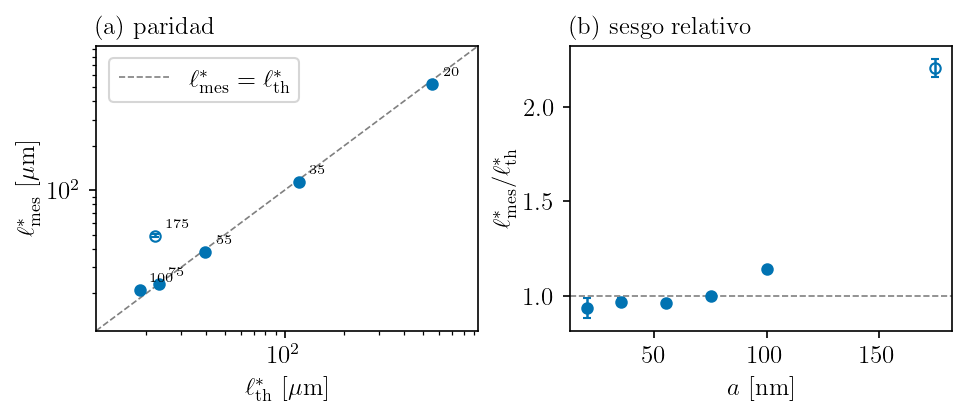

In [126]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42*TEXTWIDTH_IN))

ok = (df["2x|m-1|"] < 1.0).values

for m, fc in ((ok, COL[0]), (~ok, "none")):
    d = df[m]
    if len(d) == 0:
        continue
    a1.errorbar(d["lstar_teo"], d["lstar_med"], d["s_lstar"], fmt="o", ms=5,
                capsize=2, mfc=fc, mec=COL[0], ecolor=COL[0], ls="none")
    a2.errorbar(d["R [nm]"], d["lstar_med"]/d["lstar_teo"],
                d["s_lstar"]/d["lstar_teo"], fmt="o", ms=5,
                capsize=2, mfc=fc, mec=COL[0], ecolor=COL[0], ls="none")

vals = df[["lstar_teo", "lstar_med"]].values
lim = [0.6*vals.min(), 1.7*vals.max()]
a1.plot(lim, lim, "--", c="gray", lw=0.8, label=r"$\ell^*_{\rm mes}=\ell^*_{\rm th}$")
a1.set(xscale="log", yscale="log", xlim=lim, ylim=lim,
       xlabel=r"$\ell^*_{\rm th}$ [$\mu$m]",
       ylabel=r"$\ell^*_{\rm mes}$ [$\mu$m]")
a1.set_title("(a) paridad", loc="left")
a1.legend()
for _, r in df.iterrows():
    a1.annotate(f"{r['R [nm]']:.0f}", (r["lstar_teo"], r["lstar_med"]),
                textcoords="offset points", xytext=(5, 4), fontsize=6.5)

a2.axhline(1.0, ls="--", c="gray", lw=0.8)
a2.set(xlabel=r"$a$ [nm]", ylabel=r"$\ell^*_{\rm mes}/\ell^*_{\rm th}$")
a2.set_title("(b) sesgo relativo", loc="left")

for ax in (a1, a2):
    ax.grid(False)

fig.savefig(FIGDIR / "cbs_paridad_lstar.pdf")
plt.show()

## 5. FIG B -- Plano de observables independientes

Ambos ejes son **medidos**. El radio no es un observable directo del CBS:
corre a lo largo de la curva. Para recuperar R hay que **combinar** los dos
observables (o conocer la densidad de forma independiente).

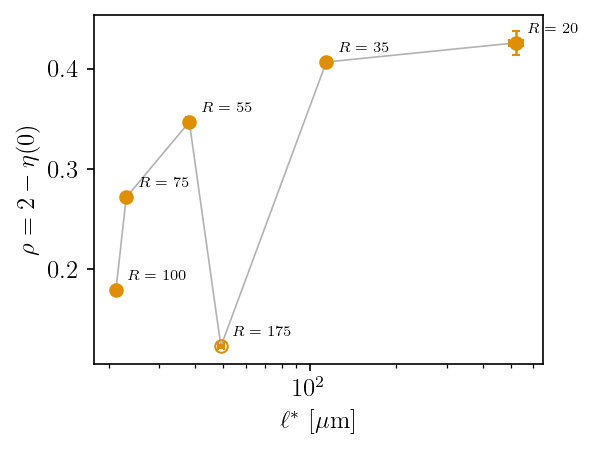

In [127]:
fig, ax = plt.subplots(figsize=(0.62*TEXTWIDTH_IN, 0.46*TEXTWIDTH_IN))

d = df.sort_values("lstar_med")
ax.plot(d["lstar_med"], d["rho"], "-", c="gray", lw=0.8, alpha=0.6, zorder=1)

for _, r in df.iterrows():
    good = r["2x|m-1|"] < 1.0
    ax.errorbar(r["lstar_med"], r["rho"],
                yerr=r["s_rho"], xerr=r["s_lstar"],
                fmt="o", ms=6, capsize=2, zorder=3,
                mfc=COL[1] if good else "none", mec=COL[1], ecolor=COL[1])
    ax.annotate(rf"$R={r['R [nm]']:.0f}$", (r["lstar_med"], r["rho"]),
                textcoords="offset points", xytext=(6, 5), fontsize=7)

ax.set(xscale="log",
       xlabel=r"$\ell^*$ [$\mu$m]",
       ylabel=r"$\rho = 2 - \eta(0)$")
ax.grid(False)

fig.savefig(FIGDIR / "cbs_plano_lstar_rho.pdf")
plt.show()

## 6. Tabla final

In [128]:
cols = ["R [nm]", "lstar_teo", "lstar_med", "s_lstar", "err_%",
        "eta0", "rho", "s_rho", "ratio", "2x|m-1|", "w/l*"]
tabla = df[cols].round(3)
tabla.to_csv(FIGDIR / "cbs_inversion_lineal_co.csv", index=False)

val = df[df["2x|m-1|"] < 1.0]
print(f"beta global      = {beta:.4f} +/- {s_beta:.4f}")
print(f"|err| medio (RGD estricto) = {val['err_%'].abs().mean():.1f} %")
print(f"|err| max   (RGD estricto) = {val['err_%'].abs().max():.1f} %")
tabla

beta global      = 0.1591 +/- 0.0129
|err| medio (RGD estricto) = 5.6 %
|err| max   (RGD estricto) = 14.0 %


,R [nm],lstar_teo,lstar_med,s_lstar,err_%,eta0,rho,s_rho,ratio,2x|m-1|,w/l*
0,20.0,557.649,521.640,29.234,-6.457,1.574,0.426,0.012,0.149,0.127,4.483
1,35.0,118.066,114.349,2.322,-3.148,1.594,0.406,0.004,0.154,0.222,21.175
2,55.0,39.776,38.179,0.675,-4.015,1.653,0.347,0.005,0.153,0.350,62.853
3,75.0,23.118,23.037,0.222,-0.348,1.728,0.272,0.002,0.159,0.477,108.143
4,100.0,18.620,21.221,0.262,13.968,1.820,0.180,0.003,0.181,0.636,134.262
5,175.0,22.283,49.180,1.102,120.703,1.877,0.123,0.002,0.351,1.112,112.192


## 7. (opcional) Mismo pipeline, polarizacion circular

Canal de **helicidad conservada** = `cross` en base circular.

In [129]:
df_c = invert(sweep_data_circular, grouped_data_circular,
              basis=circular, channel="cross", phi=0)

CAL_c   = df_c["2x|m-1|"] < 1.0
beta_c  = df_c.loc[CAL_c, "ratio"].mean()
s_beta_c = df_c.loc[CAL_c, "ratio"].std(ddof=1)

df_c["lstar_med"] = df_c["lstar_raw"] / beta_c
df_c["s_lstar"]   = df_c["s_raw"]     / beta_c
df_c["err_%"]     = 100.0 * (df_c["lstar_med"] / df_c["lstar_teo"] - 1.0)

print(f"beta (circular) = {beta_c:.4f} +/- {s_beta_c:.4f}")
print(f"beta (lineal)   = {beta:.4f} +/- {s_beta:.4f}")
df_c[["R [nm]", "lstar_teo", "lstar_med", "err_%", "eta0", "rho", "ratio"]].round(3)

beta (circular) = 0.3693 +/- 0.0165
beta (lineal)   = 0.1591 +/- 0.0129


,R [nm],lstar_teo,lstar_med,err_%,eta0,rho,ratio
0,20.0,558.642,549.177,-1.694,1.987,0.013,0.363
1,35.0,117.957,116.178,-1.509,1.983,0.017,0.364
2,55.0,39.732,38.566,-2.937,1.981,0.019,0.358
3,75.0,23.096,22.678,-1.810,1.983,0.017,0.363
4,100.0,18.552,20.026,7.949,1.988,0.012,0.399
5,175.0,22.359,33.264,48.777,1.998,0.002,0.549


/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_76611/3181373298.py:43: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); fig.savefig(FIGDIR / "cbs_calibracion_lstar_R.pdf"); plt.show()


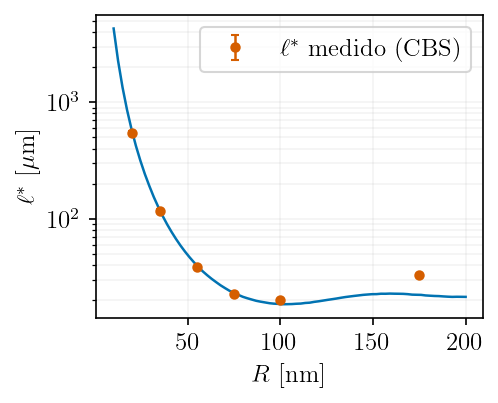

In [130]:
from luminis_mc import (
    Experiment,
    SweepManager,
    Laser, RGDMedium, Sample, FarFieldCBSSensor, StatisticsSensor, SensorsGroup,
    SimConfig, RayleighDebyeEMCPhaseFunction,
    run_simulation_parallel, postprocess_farfield_cbs,
    derived_quantities,
    set_log_level, LogLevel, LaserSource,
)
VOLUME_FRACTION = 0.10  
N_PARTICLE = 1.59
N_MEDIUM = 1.33
WAVELENGTH = 0.514             # um
MU_A_PERCENT = 0.0        
# Funcion de fase
PHASEF_THETA_MIN = 0.0
PHASEF_THETA_MAX = np.pi
PHASEF_NDIV = 10_000

def build_species(rad):
    """Una especie RGD con funcion de fase EMC (seccion eficaz NO nula)."""
    phase = RayleighDebyeEMCPhaseFunction(
        WAVELENGTH, rad, N_PARTICLE, N_MEDIUM,
        PHASEF_NDIV, PHASEF_THETA_MIN, PHASEF_THETA_MAX,
    )
    return RGDMedium(phase, rad, N_PARTICLE, N_MEDIUM, WAVELENGTH)

R_grid = np.linspace(0.010, 0.200, 80)   # um
cal = []
for rad in R_grid:
    esp = build_species(rad)             # helper del script de simulacion
    d = derived_quantities(esp, VOLUME_FRACTION)
    cal.append((rad*1000, d["transport_mean_free_path"], d["anisotropy_g"]))
cal = np.array(cal)   # columnas: R[nm], l*(R)[um], g(R)


fig, ax = plt.subplots(figsize=(0.55*TEXTWIDTH_IN, 0.45*TEXTWIDTH_IN))
ax.plot(cal[:, 0], cal[:, 1], color=COL[0])
ax.errorbar(df_c["R [nm]"], df_c["lstar_med"], df_c["s_lstar"],
            fmt="o", ms=4, capsize=2, color=COL[3], label=r"$\ell^*$ medido (CBS)")
ax.set_yscale("log"); ax.set_xlabel(r"$R$ [nm]")
ax.set_ylabel(r"$\ell^*$ [$\mu$m]"); ax.grid(alpha=0.15, which="both"); ax.legend()
fig.tight_layout(); fig.savefig(FIGDIR / "cbs_calibracion_lstar_R.pdf"); plt.show()

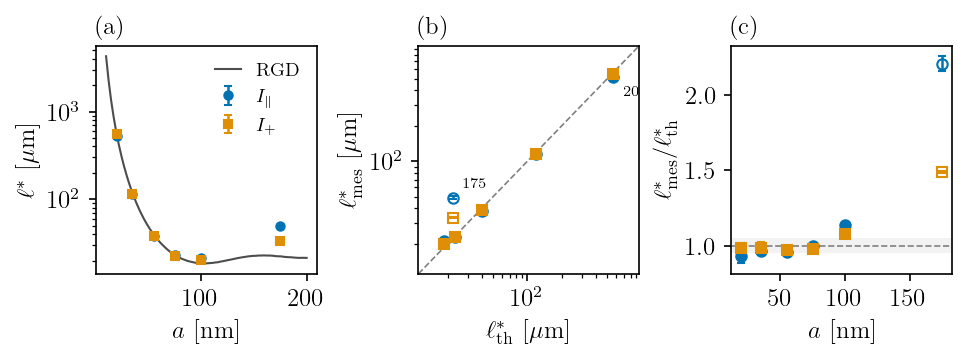

In [131]:
apply(width_frac=1.0)
fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(TEXTWIDTH_IN, 0.36*TEXTWIDTH_IN))

SERIES = [
    (df,   COL[0], "o", r"$I_\parallel$"),
    (df_c, COL[1], "s", r"$I_+$"),
]

# ---------- (a) curva de calibracion l*(a) ----------
a0.plot(cal[:, 0], cal[:, 1], color="0.3", lw=1.0, label="RGD", zorder=1)
for d_, c, mk, lb in SERIES:
    a0.errorbar(d_["R [nm]"], d_["lstar_med"], d_["s_lstar"],
                fmt=mk, ms=4, capsize=2, ls="none", color=c, label=lb, zorder=3)
a0.set_yscale("log")
a0.set_xlabel(r"$a$ [nm]")
a0.set_ylabel(r"$\ell^*$ [$\mu$m]")
a0.set_title("(a)", loc="left")
a0.legend(frameon=False, handlelength=1.4, fontsize=9)

# ---------- (b) paridad log-log ----------
for d_, c, mk, lb in SERIES:
    ok = (d_["2x|m-1|"] < 1.0).values
    for m, fc in ((ok, c), (~ok, "none")):     # hueco = fuera del rango RGD
        dd = d_[m]
        if len(dd):
            a1.errorbar(dd["lstar_teo"], dd["lstar_med"], dd["s_lstar"],
                        fmt=mk, ms=5, capsize=2, ls="none",
                        mfc=fc, mec=c, ecolor=c)

vals = np.r_[df[["lstar_teo", "lstar_med"]].values.ravel(),
             df_c[["lstar_teo", "lstar_med"]].values.ravel()]
lim = [0.6*vals.min(), 1.7*vals.max()]
a1.plot(lim, lim, "--", c="gray", lw=0.8, zorder=0)
a1.set(xscale="log", yscale="log", xlim=lim, ylim=lim,
       xlabel=r"$\ell^*_{\mathrm{th}}$ [$\mu$m]",
       ylabel=r"$\ell^*_{\mathrm{mes}}$ [$\mu$m]")
a1.set_title("(b)", loc="left")

# anotar solo los extremos, offsets a mano para que no colisionen
for R_, dx, dy in ((20, 5, -9), (175, 5, 5)):
    r = df.loc[(df["R [nm]"] - R_).abs().idxmin()]
    a1.annotate(f"{R_}", (r["lstar_teo"], r["lstar_med"]),
                textcoords="offset points", xytext=(dx, dy), fontsize=7)

# ---------- (c) sesgo relativo ----------
for d_, c, mk, lb in SERIES:
    ok = (d_["2x|m-1|"] < 1.0).values
    for m, fc in ((ok, c), (~ok, "none")):
        dd = d_[m]
        if len(dd):
            a2.errorbar(dd["R [nm]"], dd["lstar_med"]/dd["lstar_teo"],
                        dd["s_lstar"]/dd["lstar_teo"],
                        fmt=mk, ms=5, capsize=2, ls="none",
                        mfc=fc, mec=c, ecolor=c)
a2.axhline(1.0, ls="--", c="gray", lw=0.8, zorder=0)
a2.axhspan(0.95, 1.05, color="gray", alpha=0.10, lw=0)
a2.set_xlabel(r"$a$ [nm]")
a2.set_ylabel(r"$\ell^*_{\mathrm{mes}}/\ell^*_{\mathrm{th}}$")
a2.set_title("(c)", loc="left")

for ax in (a0, a1, a2):
    ax.grid(False)

fig.savefig(FIGDIR / "cbs_inversion_lstar.pdf")
plt.show()

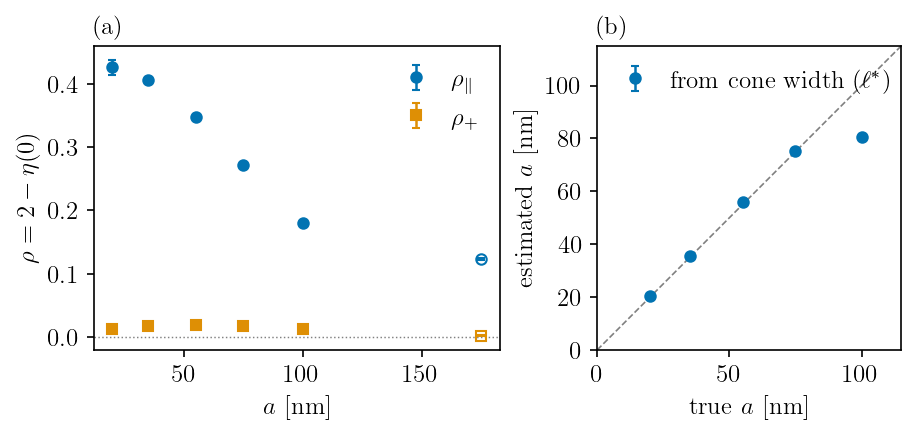

In [132]:
apply(width_frac=1.0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44*TEXTWIDTH_IN))

# ---------- (a) peak deficit rho vs particle radius ----------
RHO_SERIES = [
    (df,   COL[0], "o", r"$\rho_\parallel$"),
    (df_c, COL[1], "s", r"$\rho_+$"),
]
for d_, c, mk, lb in RHO_SERIES:
    ok = (d_["2x|m-1|"] < 1.0).values
    for m, fc in ((ok, c), (~ok, "none")):     # hollow = outside RGD regime
        dd = d_[m]
        if len(dd):
            a1.errorbar(dd["R [nm]"], dd["rho"], dd["s_rho"],
                        fmt=mk, ms=5, capsize=2, ls="none",
                        mfc=fc, mec=c, ecolor=c,
                        label=lb if fc == c else None)

a1.axhline(0.0, ls=":", c="gray", lw=0.7, zorder=0)
a1.set_xlabel(r"$a$ [nm]")
a1.set_ylabel(r"$\rho = 2 - \eta(0)$")
a1.set_title("(a)", loc="left")
a1.legend(frameon=False, handlelength=1.2)

# ---------- (b) radius inversion parity ----------
from scipy.interpolate import interp1d

imin = np.argmin(cal[:, 1])                     # minimum of l*(a)
inv_lstar_to_a = interp1d(cal[:imin+1, 1], cal[:imin+1, 0],
                          bounds_error=False, fill_value=np.nan)

d_ok  = df[df["R [nm]"] <= cal[imin, 0]]        # invertible branch only
a_est = inv_lstar_to_a(d_ok["lstar_med"])
da_dl = np.gradient(cal[:imin+1, 0], cal[:imin+1, 1])
s_aest = np.abs(interp1d(cal[:imin+1, 1], da_dl)(d_ok["lstar_med"])) * d_ok["s_lstar"]

lim = [0, 1.15*d_ok["R [nm]"].max()]
a2.plot(lim, lim, "--", c="gray", lw=0.8, zorder=0)
a2.errorbar(d_ok["R [nm]"], a_est, s_aest, fmt="o", ms=5, capsize=2,
            color=COL[0], label=r"from cone width ($\ell^*$)")
a2.set(xlim=lim, ylim=lim,
       xlabel=r"true $a$ [nm]", ylabel=r"estimated $a$ [nm]")
a2.set_aspect("equal")
a2.set_title("(b)", loc="left")
a2.legend(frameon=False, handlelength=1.2, loc="upper left")

for ax in (a1, a2):
    ax.grid(False)

fig.savefig(FIGDIR / "cbs_rho_and_radius_inversion.pdf")
plt.show()

   a_true   a_hat   s_a  rho_term_min  rgd_ok
0    20.0   20.45  0.35          0.00    True
1    35.0   35.34  0.25          3.84    True
2    55.0   55.93  0.41          0.22    True
3    75.0  159.39  6.05          0.00    True
4   100.0  133.98  2.15          0.00    True
5   175.0  159.39  1.05          0.00   False


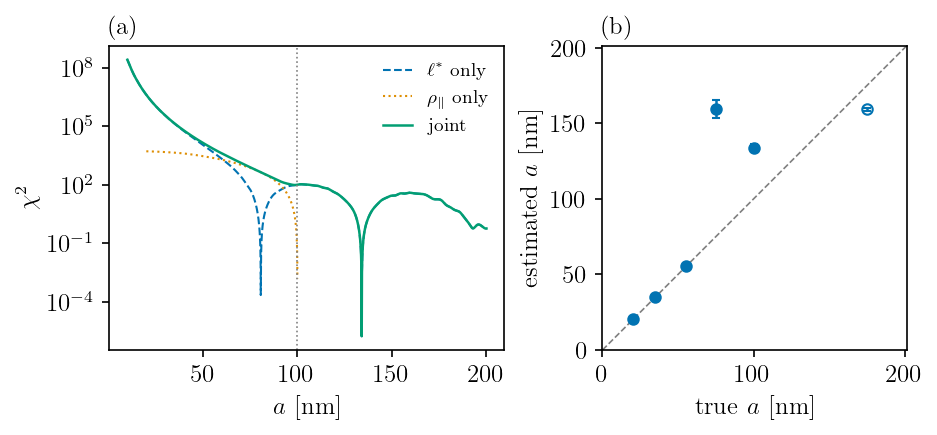

In [133]:
from scipy.interpolate import interp1d, PchipInterpolator

# =============================================================
# Joint (l*, rho) -> a inversion via chi^2 on the full a-range
# =============================================================

# --- theoretical l*(a): interpolate the full curve (both branches) ---
a_grid   = np.linspace(cal[0, 0], cal[-1, 0], 3000)
lstar_th = interp1d(cal[:, 0], cal[:, 1], kind="cubic")(a_grid)

# --- empirical rho_par(a): monotone interpolation (no functional form) ---
def fit_rho_curve(d_):
    d_s = d_.sort_values("R [nm]")
    f = PchipInterpolator(d_s["R [nm]"].values, d_s["rho"].values,
                          extrapolate=False)
    return f            # returns NaN outside the calibration range

def invert_joint(lstar_mes, s_lstar, rho_mes, s_rho, rho_fn):
    """chi^2 over the a-grid; (a_hat, sigma_a) from Delta-chi2 = 1
    on the contiguous segment around the minimum."""
    term_l = ((lstar_mes - lstar_th) / s_lstar)**2

    rho_pred = rho_fn(a_grid)
    term_r = np.where(np.isfinite(rho_pred),
                      ((rho_mes - rho_pred) / s_rho)**2, 0.0)

    chi2 = term_l + term_r
    i0 = int(np.argmin(chi2))

    if i0 in (0, len(a_grid) - 1):
        print(f"[WARN] chi2 minimum at grid boundary (a = {a_grid[i0]:.1f} nm)")

    # contiguous segment around i0 with chi2 < min + 1
    below = chi2 < chi2[i0] + 1.0
    lo = i0
    while lo > 0 and below[lo - 1]:
        lo -= 1
    hi = i0
    while hi < len(a_grid) - 1 and below[hi + 1]:
        hi += 1
    s_a = 0.5 * (a_grid[hi] - a_grid[lo])

    return a_grid[i0], s_a, chi2, term_r[i0]

# --- leave-one-out parity ---
rows = []
for i, r in df.iterrows():
    d_loo = df.drop(i)
    d_loo = d_loo[d_loo["2x|m-1|"] < 1.0]     # calibrate rho on RGD-valid points only
    rho_fn = fit_rho_curve(d_loo)
    a_hat, s_a, _, tr_min = invert_joint(r["lstar_med"], r["s_lstar"],
                                         r["rho"], r["s_rho"], rho_fn)
    if tr_min > 10:
        print(f"[WARN] a_true={r['R [nm]']:.0f}: rho term at minimum = {tr_min:.1f} "
              "(rho model does not pass through this point)")
    rows.append({"a_true": r["R [nm]"], "a_hat": a_hat, "s_a": s_a,
                 "rho_term_min": tr_min,
                 "rgd_ok": r["2x|m-1|"] < 1.0})
inv = pd.DataFrame(rows)
print(inv.round(2))

# =============================================================
# Figure: (a) chi^2 landscape for a = 100 nm, (b) parity
# =============================================================
apply(width_frac=1.0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.44*TEXTWIDTH_IN))

# ---- (a) example: the genuinely degenerate case (near the l* minimum) ----
A_EXAMPLE = 100.0
r_ex = df.loc[(df["R [nm]"] - A_EXAMPLE).abs().idxmin()]
rho_fn_full = fit_rho_curve(df[df["2x|m-1|"] < 1.0])

chi2_l = ((r_ex["lstar_med"] - lstar_th) / r_ex["s_lstar"])**2
rho_pred = rho_fn_full(a_grid)
chi2_r = np.where(np.isfinite(rho_pred),
                  ((r_ex["rho"] - rho_pred) / r_ex["s_rho"])**2, np.nan)
chi2_j = chi2_l + np.nan_to_num(chi2_r, nan=0.0)

a1.plot(a_grid, chi2_l, color=COL[0], ls="--", lw=1.0, label=r"$\ell^*$ only")
a1.plot(a_grid, chi2_r, color=COL[1], ls=":",  lw=1.0, label=r"$\rho_\parallel$ only")
a1.plot(a_grid, chi2_j, color=COL[2],          lw=1.2, label=r"joint")
a1.axvline(r_ex["R [nm]"], color="gray", ls=":", lw=0.8)
a1.set_yscale("log")
a1.set_xlabel(r"$a$ [nm]")
a1.set_ylabel(r"$\chi^2$")
a1.set_title("(a)", loc="left")
a1.legend(frameon=False, handlelength=1.5, fontsize=9)

# ---- (b) parity with LOO estimates ----
lim = [0, 1.15 * max(inv["a_true"].max(), inv["a_hat"].max())]
a2.plot(lim, lim, "--", c="gray", lw=0.8, zorder=0)
for ok, fc in ((True, COL[0]), (False, "none")):
    dd = inv[inv["rgd_ok"] == ok]
    if len(dd):
        a2.errorbar(dd["a_true"], dd["a_hat"], dd["s_a"],
                    fmt="o", ms=5, capsize=2, ls="none",
                    mfc=fc, mec=COL[0], ecolor=COL[0])
a2.set(xlim=lim, ylim=lim,
       xlabel=r"true $a$ [nm]", ylabel=r"estimated $a$ [nm]")
a2.set_aspect("equal")
a2.set_title("(b)", loc="left")

for ax in (a1, a2):
    ax.grid(False)

fig.savefig(FIGDIR / "cbs_joint_radius_inversion.pdf")
plt.show()

# TIMED

[stitch WARN] 0000_radius_0.020__rep0 ch=cross: max solape 0.071 -- revisar normalizacion angulo solido
[stitch WARN] 0001_radius_0.020__rep1 ch=cross: max solape 0.052 -- revisar normalizacion angulo solido
[stitch WARN] 0003_radius_0.020__rep3 ch=cross: max solape 0.102 -- revisar normalizacion angulo solido
[stitch WARN] 0001_radius_0.020__rep1 ch=cross: max solape 0.089 -- revisar normalizacion angulo solido
[stitch WARN] 0004_radius_0.020__rep4 ch=cross: max solape 0.073 -- revisar normalizacion angulo solido
[stitch WARN] 0000_radius_0.020__rep0 ch=cross: max solape 0.206 -- revisar normalizacion angulo solido
[stitch WARN] 0003_radius_0.020__rep3 ch=cross: max solape 0.142 -- revisar normalizacion angulo solido
[stitch WARN] 0004_radius_0.020__rep4 ch=cross: max solape 0.074 -- revisar normalizacion angulo solido
[stitch WARN] 0013_radius_0.055__rep3 ch=cross: max solape 0.057 -- revisar normalizacion angulo solido
[stitch WARN] 0014_radius_0.055__rep4 ch=cross: max solape 0.063

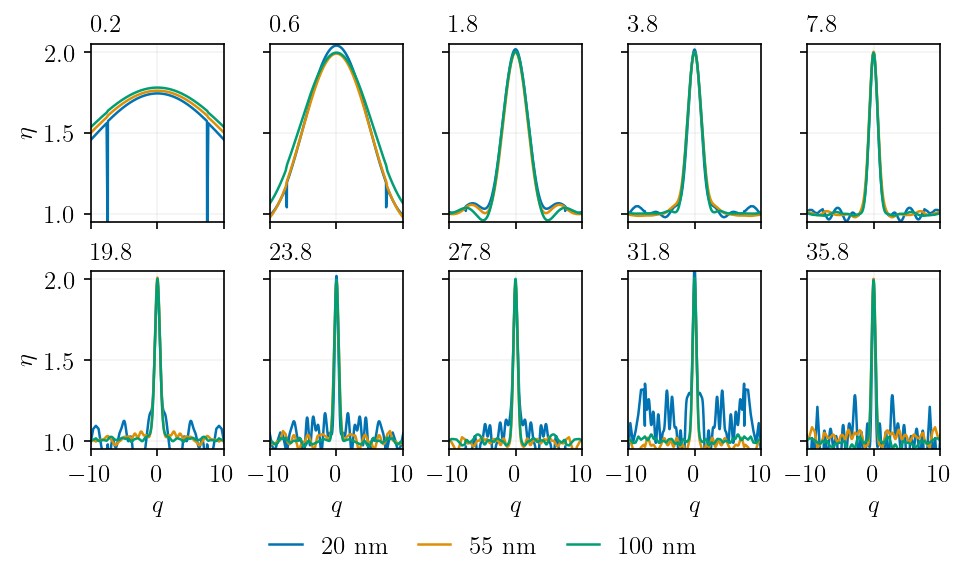

In [134]:
TIME_NBINS = 100
TIME_TMAX_TAUSTAR = 40
DT_TAU = TIME_TMAX_TAUSTAR / TIME_NBINS        # 0.4
t_of_bin = lambda i: (i - 0.5) * DT_TAU        # centro del bin i (i>=1)

time_indices = [1, 2, 5, 10, 20, 50, 60, 70, 80, 90]
radius_to_use = [0.020, 0.055, 0.100]
# radius_to_use = [0.020, 0.035, 0.055, 0.075, 0.100, 0.175]

grouped_use = [g_ for g_ in grouped_data_circular if g_.radius in radius_to_use]

fig, axes = plt.subplots(2, 5, figsize=(TEXTWIDTH_IN, 0.6*TEXTWIDTH_IN), sharex=True, sharey=True)

for iax, it in enumerate(time_indices):
    ax = axes.flat[iax]

    for c, g_ in zip(COL, grouped_use):
        _, q, m, s = profile_stats(sweep_data_circular, g_, 0, "cross", time_index=it, basis=circular)
        qs, ms, ss = mirror(q, m, s)
        ax.plot(qs, ms, color=c, label=g_.name)
    t_val = t_of_bin(it)
    ax.set_title(rf"{t_val:.1f}", loc="left")
    ax.set_xlim(-10, 10); ax.set_ylim(0.95, 2.05); ax.grid(alpha=0.15)

for ax in axes[1]:  ax.set_xlabel(r"$q$")
for ax in axes[:, 0]: ax.set_ylabel(r"$\eta$")
fig.legend(*axes[0, 0].get_legend_handles_labels(),
           ncol=6, loc="outside lower center",
           frameon=False, columnspacing=1.2, handlelength=1.3)
fig.savefig(FIGDIR / "cbs_perfiles_co_cross_circular_time.pdf")
plt.show()



In [135]:
# ---- extraccion por compuerta: ancho gaussiano y apice -----------------------
from scipy.optimize import curve_fit

def gate_metrics(sweep, g_, ch, it, phi=0, basis=linear):
    """FWHM gaussiano y eta(0) por replica en la compuerta it."""
    ws, es = [], []
    for key in g_.replicas_keys:
        _, q, E = profile_one(sweep, key, phi, ch, basis=basis, time_index=it)
        m = q < 8.0
        try:
            (A, s2), _ = curve_fit(lambda qq, A, s2: 1 + A*np.exp(-qq**2/(2*s2)),
                                   q[m], E[m], p0=[1.0, 2.0],
                                   bounds=([0, 1e-3], [1.5, 200]))
            ws.append(2*np.sqrt(2*np.log(2)*s2)); es.append(1 + A)
        except Exception:
            pass
    return (np.mean(ws), np.std(ws, ddof=1), np.mean(es), np.std(es, ddof=1)) \
           if len(ws) >= 2 else (np.nan,)*4

gates = np.arange(1, TIME_NBINS+1, 2)          # cada 2 bins basta
res_t = {g_.radius: np.array([gate_metrics(sweep_data_circular, g_, "cross", it, basis=circular)
                              for it in gates]) for g_ in grouped_use}
tt = np.array([t_of_bin(i) for i in gates])

[stitch WARN] 0003_radius_0.020__rep3 ch=cross: max solape 0.100 -- revisar normalizacion angulo solido
[stitch WARN] 0004_radius_0.020__rep4 ch=cross: max solape 0.052 -- revisar normalizacion angulo solido
[stitch WARN] 0001_radius_0.020__rep1 ch=cross: max solape 0.073 -- revisar normalizacion angulo solido
[stitch WARN] 0004_radius_0.020__rep4 ch=cross: max solape 0.062 -- revisar normalizacion angulo solido
[stitch WARN] 0000_radius_0.020__rep0 ch=cross: max solape 0.070 -- revisar normalizacion angulo solido
[stitch WARN] 0002_radius_0.020__rep2 ch=cross: max solape 0.053 -- revisar normalizacion angulo solido
[stitch WARN] 0000_radius_0.020__rep0 ch=cross: max solape 0.052 -- revisar normalizacion angulo solido
[stitch WARN] 0002_radius_0.020__rep2 ch=cross: max solape 0.054 -- revisar normalizacion angulo solido
[stitch WARN] 0003_radius_0.020__rep3 ch=cross: max solape 0.100 -- revisar normalizacion angulo solido
[stitch WARN] 0004_radius_0.020__rep4 ch=cross: max solape 0.090

/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_76611/870946684.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout(); fig.savefig(FIGDIR / "cbs_time_qw_eta0.pdf"); plt.show()


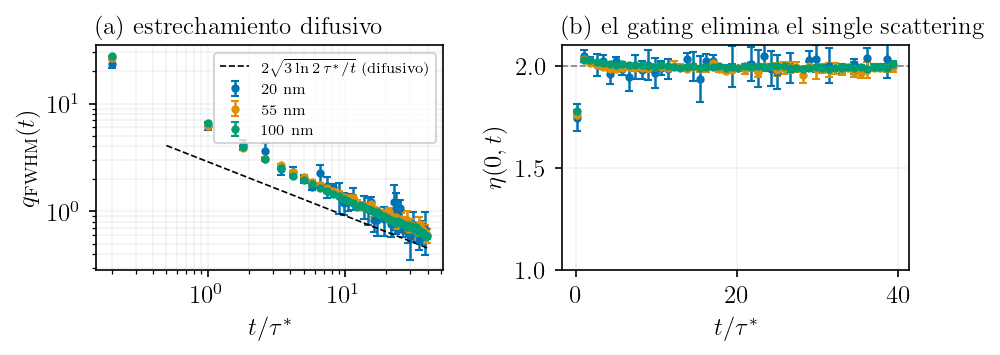

In [136]:
# ---- FIG: colapso q_w(t) y recuperacion del apice ---------------------------
fig, (a1, a2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.4*TEXTWIDTH_IN))

for c, g_ in zip(COL, grouped_use):
    M = res_t[g_.radius]
    ok = np.isfinite(M[:, 0]) & (M[:, 1] < 0.5*M[:, 0])   # descarta gates ruidosas
    a1.errorbar(tt[ok], M[ok, 0], M[ok, 1], fmt="o", ms=3, capsize=2,
                color=c, label=g_.name)
    a2.errorbar(tt[ok], M[ok, 2], M[ok, 3], fmt="o", ms=3, capsize=2, color=c)

t_th = np.geomspace(0.5, 40, 50)
a1.plot(t_th, 2*np.sqrt(3*np.log(2)/t_th), "k--", lw=0.8,
        label=r"$2\sqrt{3\ln 2\,\tau^*/t}$ (difusivo)")
a1.set(xscale="log", yscale="log", xlabel=r"$t/\tau^*$",
       ylabel=r"$q_{\rm FWHM}(t)$")
a1.set_title("(a) estrechamiento difusivo", loc="left"); a1.legend(fontsize=7)

a2.axhline(2.0, ls="--", c="gray", lw=0.8)
a2.set(xlabel=r"$t/\tau^*$", ylabel=r"$\eta(0,t)$", ylim=(1.0, 2.1))
a2.set_title("(b) el gating elimina el single scattering", loc="left")
for ax in (a1, a2): ax.grid(alpha=0.15, which="both")
fig.tight_layout(); fig.savefig(FIGDIR / "cbs_time_qw_eta0.pdf"); plt.show()